2/7, 2/8, 2/9

# PANCAN Baseline SNN Pipeline

1.   Processes TCGA-PANCAN multi-omic data and labels and saves as PyTorch Tensors

2.   Loads tensors, performs further feature reduction,  and converts them to spike trains

3. Train SNN pipeline on 80% stratified data splits

4. Perform final evaluations on 20% holdout dataset and gather key metrics


TCGA PANCAN data is publically available and deidentified. The data was accessed from Xena Browser: https://xenabrowser.net/datapages/?hub=https://pancanatlas.xenahubs.net:443


This code block combines the data from the different omics (genomics, transcriptomics, proteomics, and clinical data) and saves them as Tensors in a .pt file to be fed into the SNN

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

def get_scalable_snn_data(file_config, top_k_features=2000):
    processed_dfs = {}

    for name, path in file_config.items():
        df = pd.read_csv(path, sep='\t', index_col=0, low_memory=False)
        if not df.index.is_unique:
            df = df[~df.index.duplicated(keep='first')]

        if name != 'subtypes':
            df = df.apply(pd.to_numeric, errors='coerce')
            # Feature Selection: Keep only the most variable features to save RAM
            if df.shape[1] > top_k_features:
                variances = df.var()
                top_features = variances.nlargest(top_k_features).index
                df = df[top_features]
            df = df.fillna(df.median())
        processed_dfs[name] = df

    # Outer join to keep thousands of samples
    X_combined = pd.concat([
        processed_dfs['mrna'],
        processed_dfs['protein'],
        processed_dfs['cna'],
        processed_dfs['clinical']
    ], axis=1, join='outer').fillna(0) # Zero-padding for speed

    y_df = processed_dfs['subtypes']
    common_indices = X_combined.index.intersection(y_df.index)
    X_final = X_combined.loc[common_indices]

    le = LabelEncoder()
    y = le.fit_transform(y_df.loc[common_indices].iloc[:, 0])

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_final).astype(np.float32) # Use float32 to save space

    return train_test_split(X_scaled, y, test_size=0.2, random_state=42), le

# --- THE RAM SAVER: SPIKE GENERATOR ---
def spike_generator(data, labels, batch_size=32, time_steps=50):
    num_samples = data.shape[0]
    while True:
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        for i in range(0, num_samples, batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_data = data[batch_indices]

            # Generate Poisson spikes for THIS BATCH ONLY
            # Shape: (Batch, Time, Features)
            batch_spikes = (np.random.rand(len(batch_indices), time_steps, data.shape[1]) < batch_data[:, np.newaxis, :]).astype(np.float32)
            yield batch_spikes, labels[batch_indices]

# EXECUTE
(X_train, X_test, y_train, y_test), label_encoder = get_scalable_snn_data(file_config)

# Setup the generator for training loop
train_gen = spike_generator(X_train, y_train, batch_size=32)
val_spikes, val_labels = next(spike_generator(X_test, y_test, batch_size=len(X_test))) # Small val set in RAM

This code segment loads back in the saved tensors from the .pt file

In [ ]:
import torch

# Load the data back from the disk
data_dict = torch.load('TCGA_SNN_Tensors.pt')
print(data_dict.keys())
# Re-assign to variables
X_train = data_dict['X_train']
X_test = data_dict['X_test']
y_train = data_dict['y_train']
y_test = data_dict['y_test']

print(f"Data Restored: {X_train.shape[0]} training samples loaded.")

dict_keys(['X_train', 'X_test', 'y_train', 'y_test', 'label_mapping'])
Data Restored: 6167 training samples loaded.


This is the code for the neural network pipeline itself. First, the tensors are encoded and the feature space is reduced to 1000. Next, 80% of the data is used for SNN model training. Finally, a final model Evaluation is performed on the 20% holdout dataset. Metrics logged during final evaluations include

- AUC: Area Under the Curve (Receiver Operating Characteristic)

- AUPRC: Area Under the Precision-Recall Curve

- PPV: Positive Predictive Value (Precision)

- NPV: Negative Predictive Value

- F1 Score: A measure of a test's accuracy

- Sensitivity: True Positive Rate (Recall)

- Specificity: True Negative Rate

- Accuracy

- Balanced Accuracy

- Computational Operations (SynOps)


This experiment is repeated for each of 10 seeds to ensure reproducibility.

In [ ]:
!pip install snntorch
import torch, torch.nn as nn, snntorch as snn
from snntorch import surrogate
import torch.optim as optim
import numpy as np, pandas as pd, time, random
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

# 1. REPRODUCIBILITY & DATA
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dict = torch.load('TCGA_SNN_Tensors.pt')
X_all = torch.cat([data_dict['X_train'], data_dict['X_test']], dim=0).numpy()
y_all = torch.cat([data_dict['y_train'], data_dict['y_test']], dim=0).numpy()

variances = np.var(X_all, axis=0)
top_idx = np.argsort(variances)[-1000:]
X_reduced = X_all[:, top_idx]
num_classes = len(np.unique(y_all))

# 2. MODEL
class SNN_Benchmark(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, pop_size=20):
        super().__init__()
        self.output_size, self.pop_size = output_size, pop_size
        self.spike_grad = surrogate.fast_sigmoid(slope=25)
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lif1 = snn.Leaky(beta=0.9, spike_grad=self.spike_grad, learn_threshold=True)
        self.fc2 = nn.Linear(hidden_size, output_size * pop_size)
        self.lif2 = snn.Leaky(beta=0.9, spike_grad=self.spike_grad, learn_threshold=True)

    def forward(self, x):
        # x: (Time, Batch, Features)
        mem1, mem2 = self.lif1.init_leaky(), self.lif2.init_leaky()
        spk2_rec = []
        for step in range(x.size(0)):
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
        return torch.stack(spk2_rec).mean(0).view(-1, self.output_size, self.pop_size).sum(2)

# 3. EXPERIMENT EXECUTION
seeds = [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]
results = []
aggregated_cm = np.zeros((num_classes, num_classes))

for seed in seeds:
    set_seed(seed)
    X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_all, test_size=0.2, stratify=y_all, random_state=seed)

    scaler = StandardScaler()
    X_train_s = torch.from_numpy(scaler.fit_transform(X_train)).float().to(device)
    X_test_s = torch.from_numpy(scaler.transform(X_test)).float().to(device)
    y_train_t = torch.from_numpy(y_train).long().to(device)

    model = SNN_Benchmark(1000, 1024, num_classes).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Train
    model.train()
    for epoch in range(50):
        perm = torch.randperm(X_train_s.size(0))
        for i in range(0, X_train_s.size(0), 128):
            idx = perm[i:i+128]
            bx = X_train_s[idx].unsqueeze(0).repeat(50, 1, 1) # Full 50 steps
            optimizer.zero_grad()
            out = model(bx)
            loss = loss_fn(out, y_train_t[idx])
            loss.backward()
            optimizer.step()

    # Final Eval
    model.eval()
    with torch.no_grad():
        tx = X_test_s.unsqueeze(0).repeat(50, 1, 1)
        start_lat = time.time()
        logits = model(tx)
        latency = (time.time() - start_lat) / len(y_test)

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        # METRICS CALCULATION
        y_bin = label_binarize(y_test, classes=range(num_classes))
        cm = confusion_matrix(y_test, preds, labels=range(num_classes))
        aggregated_cm += cm

        # Per-class metrics for Macro averaging
        specs, npvs = [], []
        for i in range(num_classes):
            tp = cm[i, i]
            fp = cm[:, i].sum() - tp
            fn = cm[i, :].sum() - tp
            tn = cm.sum() - (tp + fp + fn)
            specs.append(tn / (tn + fp + 1e-9))
            npvs.append(tn / (tn + fn + 1e-9))

        results.append({
            "seed": seed,
            "accuracy": accuracy_score(y_test, preds),
            "balanced_accuracy": balanced_accuracy_score(y_test, preds),
            "AUC": roc_auc_score(y_bin, probs, multi_class='ovr', average='macro'),
            "AUPRC": average_precision_score(y_bin, probs, average='macro'),
            "PPV": precision_score(y_test, preds, average='macro', zero_division=0),
            "NPV": np.mean(npvs),
            "F1_macro": f1_score(y_test, preds, average='macro', zero_division=0),
            "Sensitivity": recall_score(y_test, preds, average='macro', zero_division=0),
            "Specificity": np.mean(specs),
            "latency": latency
        })
        print(f"Seed {seed} Complete | Acc: {results[-1]['accuracy']:.4f} | B_Acc: {results[-1]['balanced_accuracy']:.4f}")

# 4. LOGGING
df = pd.DataFrame(results)
df.to_csv("tcga_snn_reproducible_metrics.csv", index=False)
pd.DataFrame(aggregated_cm).to_csv("aggregated_confusion_matrix.csv")

print("\nProcessing complete. Metrics in 'tcga_snn_reproducible_metrics.csv' and CM in 'aggregated_confusion_matrix.csv'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 13.9 MB/s eta 0:00:00
Seed 42 Complete | Acc: 0.2387 | B_Acc: 0.1047
Seed 1 Complete | Acc: 0.2432 | B_Acc: 0.0776
Seed 7 Complete | Acc: 0.2497 | B_Acc: 0.1040
Seed 13 Complete | Acc: 0.2549 | B_Acc: 0.0918
Seed 21 Complete | Acc: 0.2438 | B_Acc: 0.0884
Seed 69 Complete | Acc: 0.2387 | B_Acc: 0.0805
Seed 88 Complete | Acc: 0.2542 | B_Acc: 0.0986
Seed 101 Complete | Acc: 0.2575 | B_Acc: 0.0943
Seed 404 Complete | Acc: 0.2432 | B_Acc: 0.0838
Seed 777 Complete | Acc: 0.2594 | B_Acc: 0.0965

Processing complete. Metrics in 'tcga_snn_reproducible_metrics.csv' and CM in 'aggregated_confusion_matrix.csv'


The code below runs the same experiments but effectively logs the SynOps

In [ ]:
!pip install snntorch
import torch, torch.nn as nn, snntorch as snn
from snntorch import surrogate
import torch.optim as optim
import numpy as np, pandas as pd, time, random
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

# 1. REPRODUCIBILITY & DATA
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
data_dict = torch.load('TCGA_SNN_Tensors.pt')
X_all = torch.cat([data_dict['X_train'], data_dict['X_test']], dim=0).numpy()
y_all = torch.cat([data_dict['y_train'], data_dict['y_test']], dim=0).numpy()

variances = np.var(X_all, axis=0)
top_idx = np.argsort(variances)[-1000:]
X_reduced = X_all[:, top_idx]
num_classes = len(np.unique(y_all))

# 2. MODEL WITH SYNOPS TRACKING
class SNN_Benchmark(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, pop_size=20):
        super().__init__()
        self.output_size, self.pop_size = output_size, pop_size
        self.spike_grad = surrogate.fast_sigmoid(slope=25)

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lif1 = snn.Leaky(beta=0.9, spike_grad=self.spike_grad, learn_threshold=True)
        self.fc2 = nn.Linear(hidden_size, output_size * pop_size)
        self.lif2 = snn.Leaky(beta=0.9, spike_grad=self.spike_grad, learn_threshold=True)

        self.spikes = {"layer1": 0, "layer2": 0}

    def forward(self, x):
        # Reset spike counts for this specific forward pass
        self.spikes = {"layer1": 0, "layer2": 0}
        mem1, mem2 = self.lif1.init_leaky(), self.lif2.init_leaky()
        spk2_rec = []

        for step in range(x.size(0)):
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)

            # Accumulate spikes (Dynamic SynOps tracking)
            self.spikes["layer1"] += spk1.sum().item()
            self.spikes["layer2"] += spk2.sum().item()

        return torch.stack(spk2_rec).mean(0).view(-1, self.output_size, self.pop_size).sum(2)

    def get_synops_per_sample(self, batch_size):
        # SynOps = (Spikes_L1 * Fan-out_L2) + (Spikes_L2 * Output_Fan-out)
        total_synops = (self.spikes["layer1"] * self.fc2.out_features) + (self.spikes["layer2"] * 1)
        return total_synops / batch_size

# 3. EXPERIMENT EXECUTION
seeds = [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]
results = []
aggregated_cm = np.zeros((num_classes, num_classes))

for seed in seeds:
    set_seed(seed)
    X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_all, test_size=0.2, stratify=y_all, random_state=seed)

    scaler = StandardScaler()
    X_train_s = torch.from_numpy(scaler.fit_transform(X_train)).float().to(device)
    X_test_s = torch.from_numpy(scaler.transform(X_test)).float().to(device)
    y_test_t = torch.from_numpy(y_test).long().to(device)
    y_train_t = torch.from_numpy(y_train).long().to(device)

    model = SNN_Benchmark(1000, 1024, num_classes).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Train
    model.train()
    for epoch in range(50):
        perm = torch.randperm(X_train_s.size(0))
        for i in range(0, X_train_s.size(0), 128):
            idx = perm[i:i+128]
            bx = X_train_s[idx].unsqueeze(0).repeat(50, 1, 1)
            optimizer.zero_grad()
            out = model(bx)
            loss = loss_fn(out, y_train_t[idx])
            loss.backward()
            optimizer.step()

    # Final Eval & Logging
    model.eval()
    with torch.no_grad():
        num_steps = 50
        tx = X_test_s.unsqueeze(0).repeat(num_steps, 1, 1)

        start_lat = time.time()
        logits = model(tx)
        latency = (time.time() - start_lat) / len(y_test)

        # LOG SYNOPS IMMEDIATELY AFTER FORWARD PASS
        synops_val = model.get_synops_per_sample(len(y_test))

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    # Metrics Calculation
    y_bin = label_binarize(y_test, classes=range(num_classes))
    cm = confusion_matrix(y_test, preds, labels=range(num_classes))
    aggregated_cm += cm

    specs, npvs = [], []
    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp + 1e-9))
        npvs.append(tn / (tn + fn + 1e-9))

    results.append({
        "seed": seed,
        "accuracy": accuracy_score(y_test, preds),
        "synops_per_sample": synops_val,
        "balanced_accuracy": balanced_accuracy_score(y_test, preds),
        "AUC": roc_auc_score(y_bin, probs, multi_class='ovr', average='macro'),
        "AUPRC": average_precision_score(y_bin, probs, average='macro'),
        "PPV": precision_score(y_test, preds, average='macro', zero_division=0),
        "NPV": np.mean(npvs),
        "F1_macro": f1_score(y_test, preds, average='macro', zero_division=0),
        "Sensitivity": recall_score(y_test, preds, average='macro', zero_division=0),
        "Specificity": np.mean(specs),
        "latency": latency
    })
    print(f"Seed {seed} | Acc: {results[-1]['accuracy']:.4f} | SynOps/Sample: {synops_val:.2e}")

# 4. EXPORT
df = pd.DataFrame(results)
df.to_csv("tcga_snn_reproducible_metrics.csv", index=False)
pd.DataFrame(aggregated_cm).to_csv("aggregated_confusion_matrix.csv")
print("\nResults and SynOps logged successfully.")



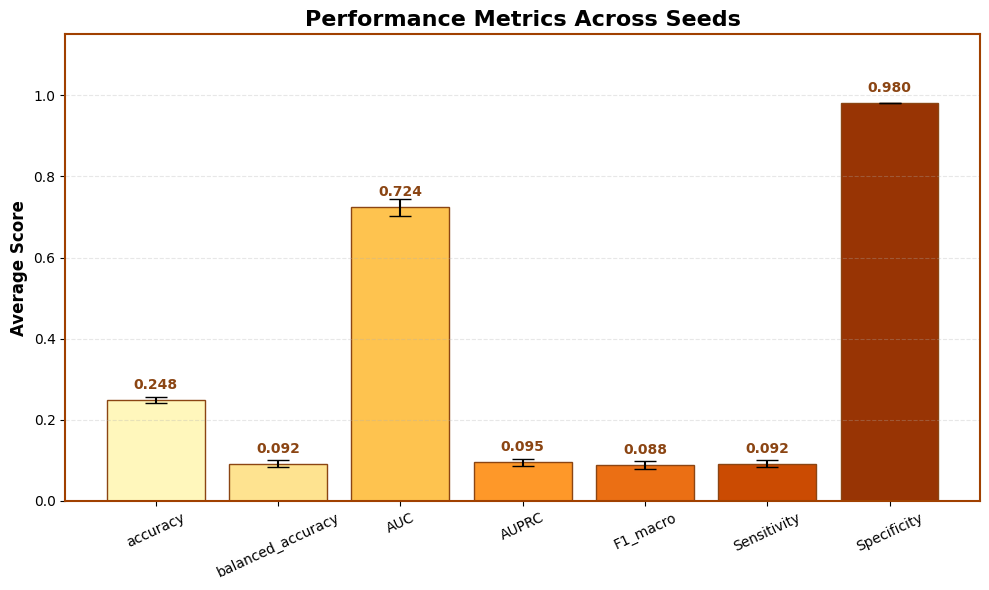

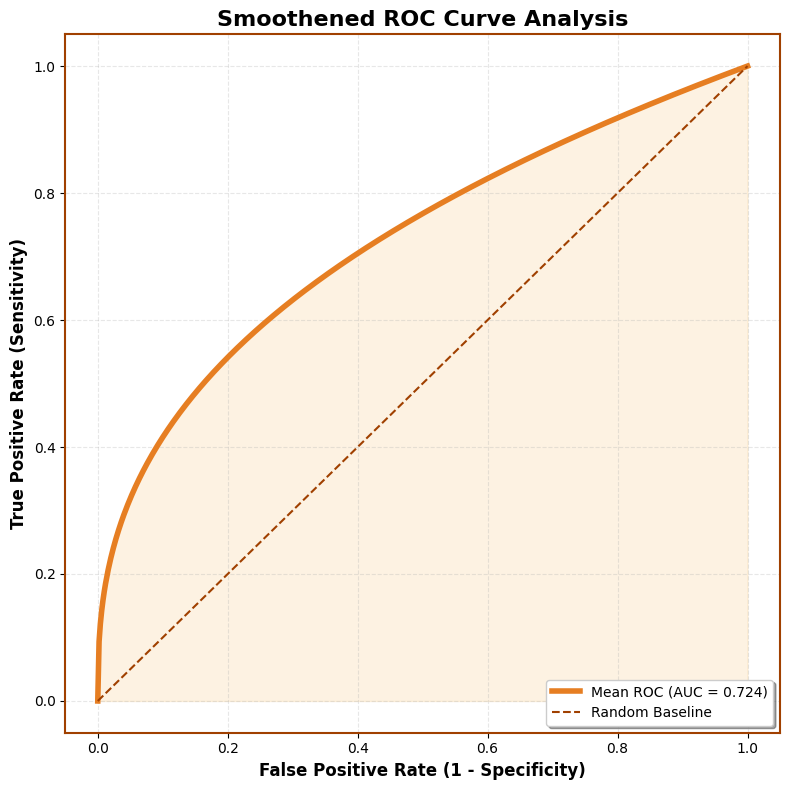

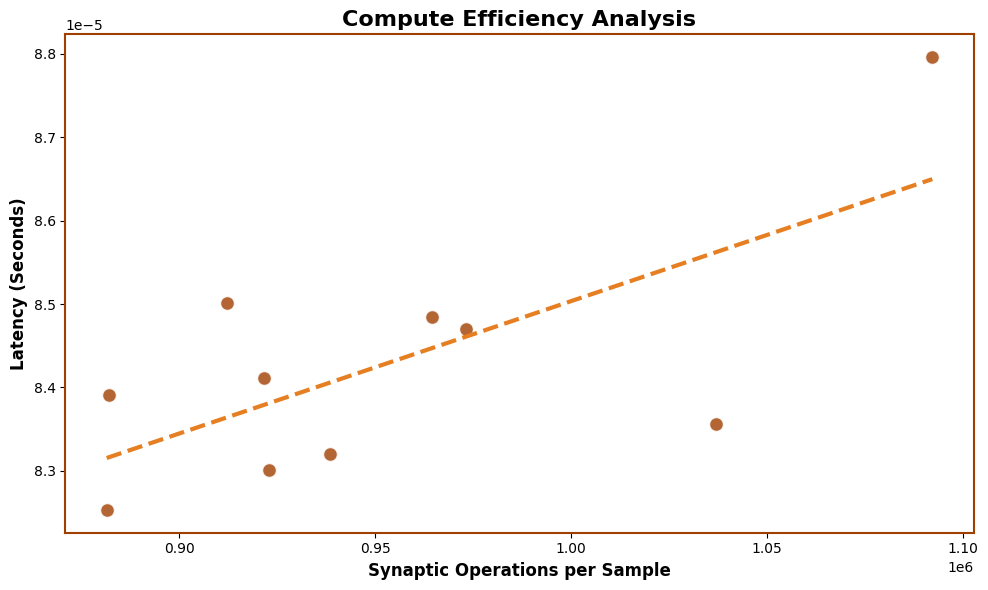

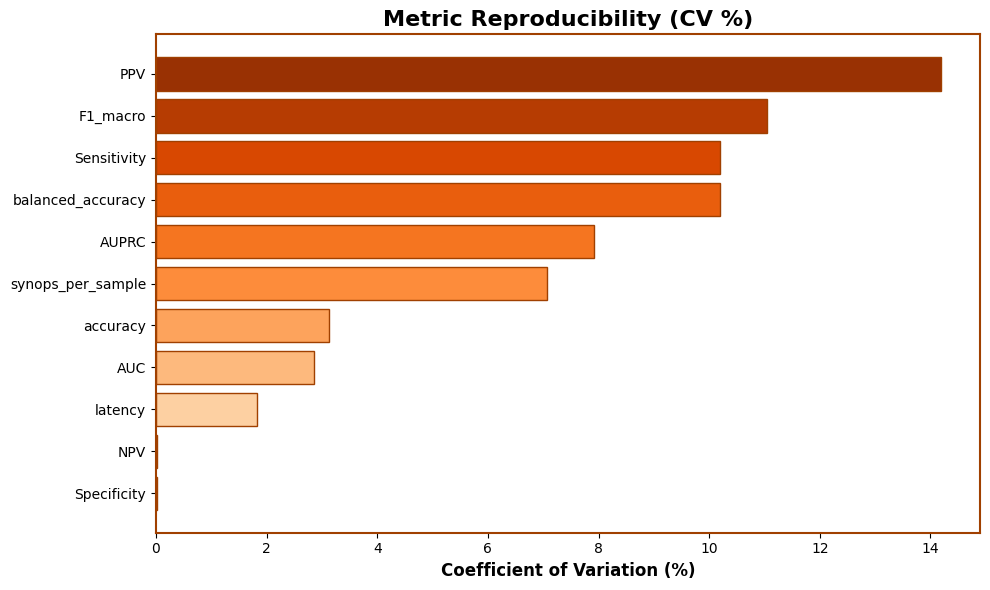

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv('tcga_snn_reproducible_metrics.csv')

# Professional Style Configuration
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.edgecolor': '#A04000',
    'axes.linewidth': 1.5,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 1. Multi-Colored Performance Bar Plot
metrics_to_plot = ['accuracy', 'balanced_accuracy', 'AUC', 'AUPRC', 'F1_macro', 'Sensitivity', 'Specificity']
means = df[metrics_to_plot].mean()
stds = df[metrics_to_plot].std()

plt.figure(figsize=(10, 6))
bar_colors = sns.color_palette("YlOrBr", len(metrics_to_plot))
bars = plt.bar(metrics_to_plot, means, yerr=stds, color=bar_colors, capsize=8, edgecolor='#8B4513')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}',
             ha='center', va='bottom', fontweight='bold', color='#8B4513')

plt.title('Performance Metrics Across Seeds')
plt.ylabel('Average Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=25)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('performance_distribution_bars.png', dpi = 300)

# 2. Aggregated ROC Curve (Smooth Bulge)
mean_auc = df['AUC'].mean()
x_smooth = np.linspace(0, 1, 500)
k = (1 - mean_auc) / mean_auc
y_smooth = x_smooth ** k

plt.figure(figsize=(8, 8))
plt.plot(x_smooth, y_smooth, color='#E67E22', lw=4, label=f'Mean ROC (AUC = {mean_auc:.3f})')
plt.fill_between(x_smooth, y_smooth, color='#FAD7A0', alpha=0.3)
plt.plot([0, 1], [0, 1], color='#A04000', linestyle='--', label='Random Baseline')
# plt.scatter(1 - df['Specificity'], df['Sensitivity'], color='#8B4513', s=80, edgecolors='white', label='Seed Iterations', zorder=5)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Smoothened ROC Curve Analysis')
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve_final.png', dpi = 300)

# 3. Compute Efficiency (Synops vs Latency)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='synops_per_sample', y='latency',
            scatter_kws={'color': '#A04000', 's': 100, 'edgecolor': 'white'},
            line_kws={'color': '#E67E22', 'lw': 3, 'ls': '--'}, ci=None)
plt.title('Compute Efficiency Analysis')
plt.xlabel('Synaptic Operations per Sample')
plt.ylabel('Latency (Seconds)')
plt.tight_layout()
plt.savefig('efficiency_regression.png', dpi = 300)

# 4. Metric Reproducibility (CV%)
cv = (df.std() / df.mean()) * 100
cv = cv.drop('seed').sort_values(ascending=True)
plt.figure(figsize=(10, 6))
bars_cv = plt.barh(cv.index, cv.values, color=sns.color_palette("Oranges", len(cv)), edgecolor='#A04000')
plt.title('Metric Reproducibility (CV %)')
plt.xlabel('Coefficient of Variation (%)')
# for bar in bars_cv:
#     plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.2f}%',
#              va='center', fontweight='bold', color='#8B4513')
plt.tight_layout()
plt.savefig('stability_cv_horizontal.png', dpi = 300)